In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from scipy import stats as st

In [ ]:
df_csv = pd.read_csv("/content/chicago_crimes_and_stations_2024_processed.csv")
df_csv = df_csv.drop(["Unnamed: 0"], axis=1)
# df_csv['Distance Crime To Police Station'] = df_csv['Distance Crime To Police Station'].round(4)

## Análisis del dataset en gral

In [ ]:
# Mostrar las primeras filas (las 5 primeras por defecto)
df_csv.head()

,IUCR,Primary Type,Location Description,Arrest,Domestic,Beat,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Nearest Police Station District,Nearest Police Station District Name,Distance Crime To Police Station,Season,Day,Day Time
0,1310,CRIMINAL DAMAGE,APARTMENT,False,False,332,5,43,14,1186817.0,1860189.0,41.771470,-87.605748,3,3,Grand Crossing,1367.540845,Winter,Tuesday,Night
1,1365,CRIMINAL TRESPASS,APARTMENT,True,True,223,3,38,26,1179661.0,1873623.0,41.808501,-87.630560,2,2,Wentworth,1380.313916,Winter,Tuesday,Night
2,0498,BATTERY,HOTEL / MOTEL,False,True,834,18,70,04B,1145740.0,1853048.0,41.752749,-87.708864,8,8,Chicago Lawn,3982.098345,Winter,Tuesday,Night
3,1320,CRIMINAL DAMAGE,STREET,False,False,321,20,42,14,1184362.0,1861188.0,41.774269,-87.605748,3,3,Grand Crossing,1005.009383,Winter,Tuesday,Night
4,0460,BATTERY,SIDEWALK,False,False,2531,29,25,08B,1137458.0,1907694.0,41.902858,-87.765574,25,25,Grand Central,1797.243049,Winter,Tuesday,Night


In [ ]:
df_csv.describe()

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,257514.000000,257514.000000,257514.000000,2.575140e+05,2.575140e+05,257514.000000,257514.000000,257514.000000,257514.000000
mean,1157.056339,23.185023,36.182437,1.165281e+06,1.887738e+06,41.847534,-87.668927,11.340712,1998.281721
std,709.339850,13.950074,21.606347,1.616071e+04,3.153780e+04,0.086723,0.051320,7.088088,1213.955887
min,111.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.768200,1.000000,12.262025
25%,533.000000,10.000000,22.000000,1.154005e+06,1.860559e+06,41.772692,-87.705488,5.000000,1219.384303
50%,1034.000000,23.000000,32.000000,1.167128e+06,1.894416e+06,41.866093,-87.656973,10.000000,1852.857265
75%,1732.000000,34.000000,53.000000,1.176638e+06,1.910460e+06,41.910074,-87.630560,17.000000,2509.772804
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,14166.024970


In [ ]:
df_csv.describe(percentiles=[.1,.9,.95])

,Beat,Ward,Community Area,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Distance Crime To Police Station
count,257514.000000,257514.000000,257514.000000,2.575140e+05,2.575140e+05,257514.000000,257514.000000,257514.000000,257514.000000
mean,1157.056339,23.185023,36.182437,1.165281e+06,1.887738e+06,41.847534,-87.668927,11.340712,1998.281721
std,709.339850,13.950074,21.606347,1.616071e+04,3.153780e+04,0.086723,0.051320,7.088088,1213.955887
min,111.000000,1.000000,1.000000,1.092647e+06,1.813897e+06,41.644590,-87.768200,1.000000,12.262025
10%,233.000000,5.000000,7.000000,1.143544e+06,1.846879e+06,41.735088,-87.765574,2.000000,738.416582
50%,1034.000000,23.000000,32.000000,1.167128e+06,1.894416e+06,41.866093,-87.656973,10.000000,1852.857265
90%,2222.000000,43.000000,69.000000,1.183960e+06,1.929402e+06,41.961957,-87.605748,22.000000,3348.752934
95%,2511.000000,47.000000,71.000000,1.190861e+06,1.937046e+06,41.983121,-87.604506,25.000000,3900.273708
max,2535.000000,50.000000,77.000000,1.205119e+06,1.951493e+06,42.022548,-87.568349,31.000000,14166.024970


In [ ]:
df_csv.describe(include='object')

,IUCR,Primary Type,Location Description,FBI Code,Nearest Police Station District,Nearest Police Station District Name,Season,Day,Day Time
count,257514,257514,256468,257514,257514,257514,257514,257514,257514
unique,340,31,128,26,23,23,4,7,4
top,0486,THEFT,STREET,06,3,Grand Crossing,Summer,Monday,Afternoon
freq,20318,60292,69375,61064,23940,23940,70107,37889,80280


In [ ]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257514 entries, 0 to 257513
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   IUCR                                  257514 non-null  object 
 1   Primary Type                          257514 non-null  object 
 2   Location Description                  256468 non-null  object 
 3   Arrest                                257514 non-null  bool   
 4   Domestic                              257514 non-null  bool   
 5   Beat                                  257514 non-null  int64  
 6   Ward                                  257514 non-null  int64  
 7   Community Area                        257514 non-null  int64  
 8   FBI Code                              257514 non-null  object 
 9   X Coordinate                          257514 non-null  float64
 10  Y Coordinate                          257514 non-null  float64
 11  

In [ ]:
df_csv['Arrest'].value_counts(normalize=True).round(4) * 100

,proportion
Arrest,
False,86.22
True,13.78


In [ ]:
df_csv['Arrest'].value_counts()

,count
Arrest,
False,222020
True,35494


In [ ]:
percent = df_csv['Domestic'].value_counts(normalize=True).round(4) * 100
percent.head()

,proportion
Domestic,
False,81.63
True,18.37


In [ ]:
df_duplicated = df_csv.duplicated()
print("Cantidad de datos duplicados:", df_duplicated.sum())

Cantidad de datos duplicados: 3828


In [ ]:
df_csv.duplicated().head()

,0
0,False
1,False
2,False
3,False
4,False


In [ ]:
print(f"Columnas del dataframe:\n{df_csv.dtypes}\n")

Columnas del dataframe:
IUCR                                     object
Primary Type                             object
Location Description                     object
Arrest                                     bool
Domestic                                   bool
Beat                                      int64
Ward                                      int64
Community Area                            int64
FBI Code                                 object
X Coordinate                            float64
Y Coordinate                            float64
Latitude                                float64
Longitude                               float64
Crime District                            int64
Nearest Police Station District          object
Nearest Police Station District Name     object
Distance Crime To Police Station        float64
Season                                   object
Day                                      object
Day Time                                 object
dtype: object



## EDA

### Análisis de las variables numéricas

In [ ]:
# Función para graficar
def plot_histograma(data, column, figsize=(6, 3), bins=15, kde=True, mvd=True, snk=False):
    skewness = (data[column]).skew()
    kurtosis = (data[column]).kurt()
    media = (data[column]).mean()
    var = (data[column]).var()
    std = (data[column]).std()
    plt.figure(figsize=figsize)
    plt.grid(axis='y')
    sns.histplot(data[column], bins=bins, kde=kde)
    if snk:
        plt.figtext(0.7, 0.8, f'Asimetría: {skewness:.2f}', fontsize=10, color='blue')
        plt.figtext(0.715, 0.73, f'Curtosis: {kurtosis:.2f}', fontsize=10, color='blue')
    plt.axvline(media, color='red', linestyle='--', label='Media')
    if mvd:
        plt.figtext(0.15, 0.8, f'Media: {media:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.73, f'Var: {var:.2f}', fontsize=10, color='red')
        plt.figtext(0.15, 0.66, f'Std: {std:.2f}', fontsize=10, color='red')
    plt.title(f'Variable: {column}')
    plt.xlabel(f'{column}')
    plt.ylabel('Frecuencia')
    plt.show()

    return

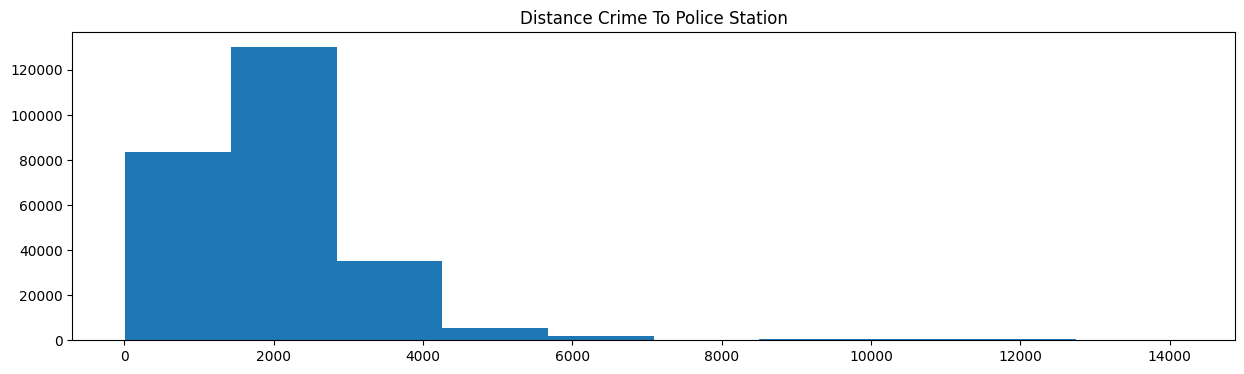

In [ ]:
fig, ax = plt.subplots(1, figsize=(15, 4))

ax.hist(df_csv['Distance Crime To Police Station'])   # edad
ax.set_title('Distance Crime To Police Station')

plt.show()

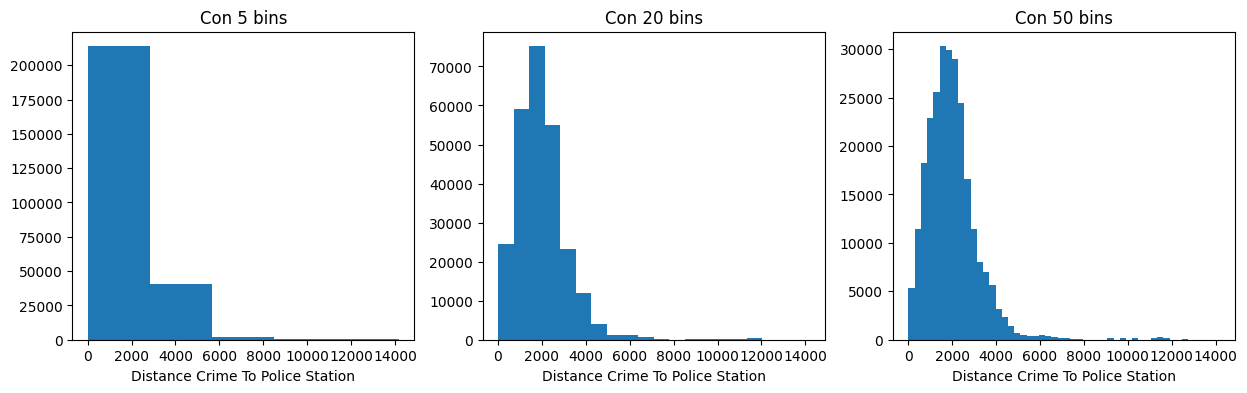

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(df_csv['Distance Crime To Police Station'], bins=5)
ax[0].set_title('Con 5 bins')
ax[0].set_xlabel('Distance Crime To Police Station')
ax[1].hist(df_csv['Distance Crime To Police Station'], bins=20)
ax[1].set_title('Con 20 bins')
ax[1].set_xlabel('Distance Crime To Police Station')
ax[2].hist(df_csv['Distance Crime To Police Station'], bins=50)
ax[2].set_title('Con 50 bins')
ax[2].set_xlabel('Distance Crime To Police Station')

plt.show()

#### 1. Medidas de tendencia central: media, mediana y moda

Media

In [ ]:
np.mean(df_csv['Distance Crime To Police Station'])

np.float64(1998.2817213480726)

In [ ]:
df_csv['Distance Crime To Police Station'].mean()

np.float64(1998.2817213480726)

Mediana

In [ ]:
np.median(df_csv['Distance Crime To Police Station'])

np.float64(1852.8572649309583)

In [ ]:
df_csv['Distance Crime To Police Station'].median()

1852.8572649309583

Moda

In [ ]:
df_csv['Distance Crime To Police Station'].mode()[0]

np.float64(3836.500799270364)

In [ ]:
mode_age = st.mode(df_csv['Distance Crime To Police Station'], keepdims=False)  # con SciPy
mode_age.mode

np.float64(3836.500799270364)

Visualizamos

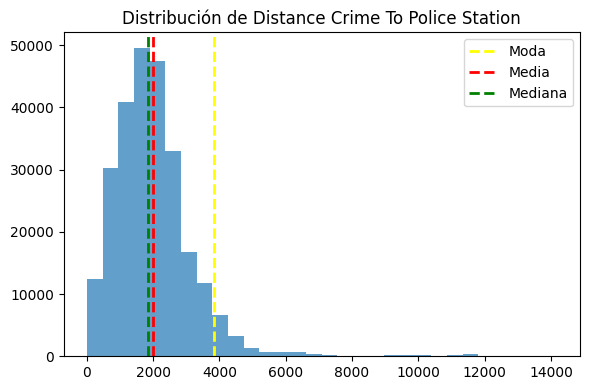

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.hist(df_csv['Distance Crime To Police Station'], bins=30, alpha=0.7) # dibujar histograma
ax.axvline(df_csv['Distance Crime To Police Station'].mode()[0], color='yellow', ls='--', lw=2, label='Moda')
ax.axvline(df_csv['Distance Crime To Police Station'].mean(), color='red', ls='--', lw=2, label='Media')
ax.axvline(df_csv['Distance Crime To Police Station'].median(), color='green', ls='--', lw=2, label='Mediana')
ax.set_title('Distribución de Distance Crime To Police Station')
ax.legend()

plt.tight_layout()
plt.show()

#### 2. Medidas de dispersión: varianza y desviación estándar


In [ ]:
# Calculamos la media, varianza y desviación estándar
media = df_csv['Distance Crime To Police Station'].mean()
var = df_csv['Distance Crime To Police Station'].var()
std_dev = df_csv['Distance Crime To Police Station'].std()
print(f'La media de Distance Crime To Police Station es {media:.2f} mm., \nla varianza es {var:.4f} mm. y \nla desviación estándar es {std_dev:.4f} mm.')

La media de Distance Crime To Police Station es 1998.28 mm., 
la varianza es 1473688.8965 mm. y 
la desviación estándar es 1213.9559 mm.


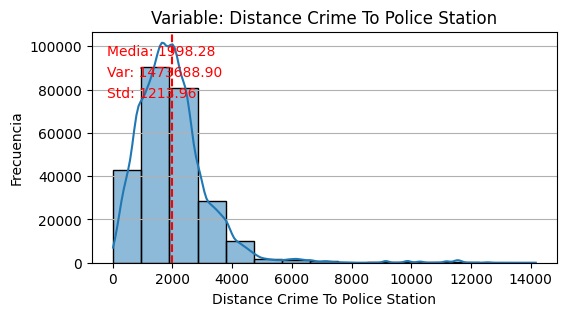

In [ ]:
# Usamos la función que definimos para graficar (ver sección HELPER FUNCTIONS)
plot_histograma(df_csv, 'Distance Crime To Police Station')

KDE: Kernel Density Estimation --> estimar la función de densidad de probabilidad (PDF)


<Axes: xlabel='Distance Crime To Police Station', ylabel='Density'>

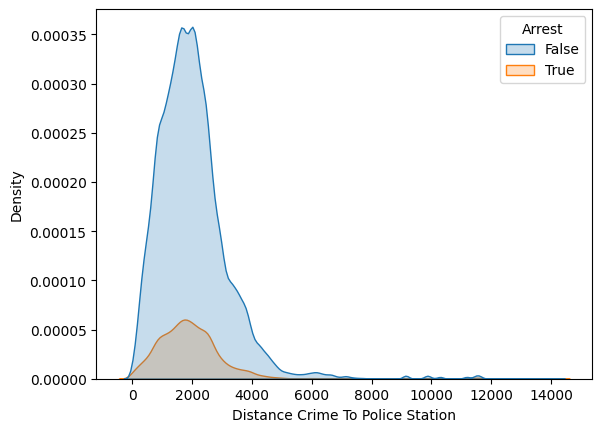

In [ ]:
sns.kdeplot(data=df_csv, x='Distance Crime To Police Station', hue='Arrest', fill=True)

#### 3. Cuantiles y rango intercuartil

Violinplot: cuando necesito comparar distribuciones entre grupos, identificar distribuciones complejas, etc.


In [ ]:
# sns.violinplot(data=df_csv, x='Distance Crime To Police Station', y='Arrest', color="lightblue", inner="box")

In [ ]:
# sns.violinplot(data=df_csv, x='Distance Crime To Police Station', y='Arrest', color="lightblue", inner="quartile")

#### 4. Medidas de forma: skewness (asimetría) y curtosis

In [ ]:
# Con Pandas
print(f"Asímetría de la variable Distance Crime To Police Station: {df_csv['Distance Crime To Police Station'].skew()}")
print(f"Curtosis de la variable Distance Crime To Police Station: {df_csv['Distance Crime To Police Station'].kurtosis()}")

Asímetría de la variable Distance Crime To Police Station: 2.4519086024097883
Curtosis de la variable Distance Crime To Police Station: 13.70063416266321


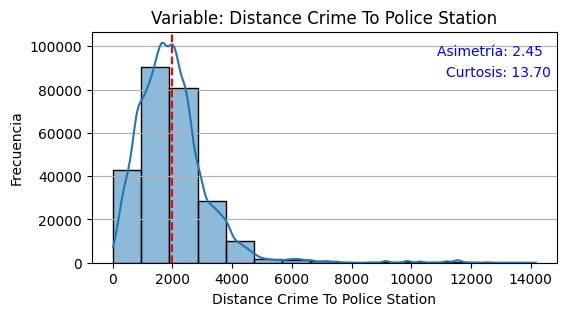

In [ ]:
plot_histograma(df_csv, 'Distance Crime To Police Station',mvd= False, snk=True)

QQPlot

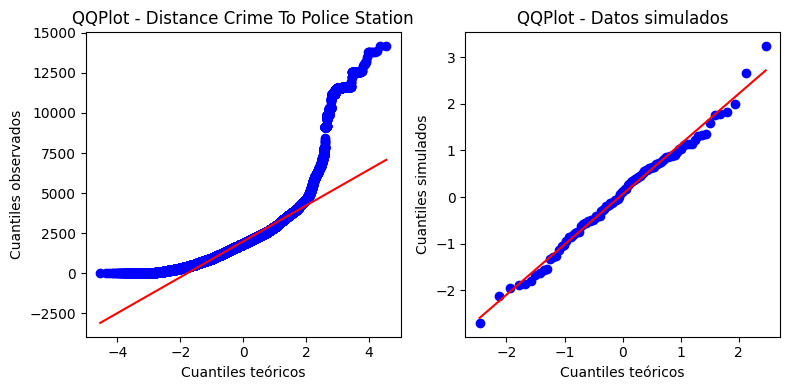

In [ ]:
fig, (ax_ping, ax_normal) = plt.subplots(1, 2, figsize=(8, 4))

# QQPlot para largo de aleta de pingüinos
st.probplot(df_csv['Distance Crime To Police Station'], dist="norm", plot=ax_ping)
ax_ping.set_title("QQPlot - Distance Crime To Police Station")
ax_ping.set_xlabel("Cuantiles teóricos")
ax_ping.set_ylabel("Cuantiles observados")

# QQPlot para datos aleatorios con distribución normal
data = np.random.normal(loc=0, scale=1, size=100)
st.probplot(data, dist="norm", plot=ax_normal)
ax_normal.set_title("QQPlot - Datos simulados")
ax_normal.set_xlabel("Cuantiles teóricos")
ax_normal.set_ylabel("Cuantiles simulados")

plt.tight_layout()
plt.show()

### Análisis de las variables categóricas

#### a. Exploramos las variables categóricas del dataset

In [ ]:
# Convertimos columnas del dataset del Titanic al tipo correcto
df_csv['Primary Type'] = df_csv['Primary Type'].astype('category')
df_csv['Location Description'] = df_csv['Location Description'].astype('category')
df_csv['Arrest'] = df_csv['Arrest'].astype('category')
df_csv['Domestic'] = df_csv['Domestic'].astype('category')
df_csv['Nearest Police Station District Name'] = df_csv['Nearest Police Station District Name'].astype('category')
df_csv['Season'] = df_csv['Season'].astype('category')
df_csv['Day'] = df_csv['Day'].astype('category')
df_csv['Day Time'] = df_csv['Day Time'].astype('category')

In [ ]:
df_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 257514 entries, 0 to 257513
Data columns (total 20 columns):
 #   Column                                Non-Null Count   Dtype   
---  ------                                --------------   -----   
 0   IUCR                                  257514 non-null  object  
 1   Primary Type                          257514 non-null  category
 2   Location Description                  256468 non-null  category
 3   Arrest                                257514 non-null  category
 4   Domestic                              257514 non-null  category
 5   Beat                                  257514 non-null  int64   
 6   Ward                                  257514 non-null  int64   
 7   Community Area                        257514 non-null  int64   
 8   FBI Code                              257514 non-null  object  
 9   X Coordinate                          257514 non-null  float64 
 10  Y Coordinate                          257514 non-null  f

In [ ]:
df_csv.describe(include='category')

# count = cant. de datos no nulos
# unique = cantidad de categorias distintas
# top = categoria con mayor frecuencia
# freq = frecuencia de la categoria top

,Primary Type,Location Description,Arrest,Domestic,Nearest Police Station District Name,Season,Day,Day Time
count,257514,256468,257514,257514,257514,257514,257514,257514
unique,31,128,2,2,23,4,7,4
top,THEFT,STREET,False,False,Grand Crossing,Summer,Monday,Afternoon
freq,60292,69375,222020,210220,23940,70107,37889,80280


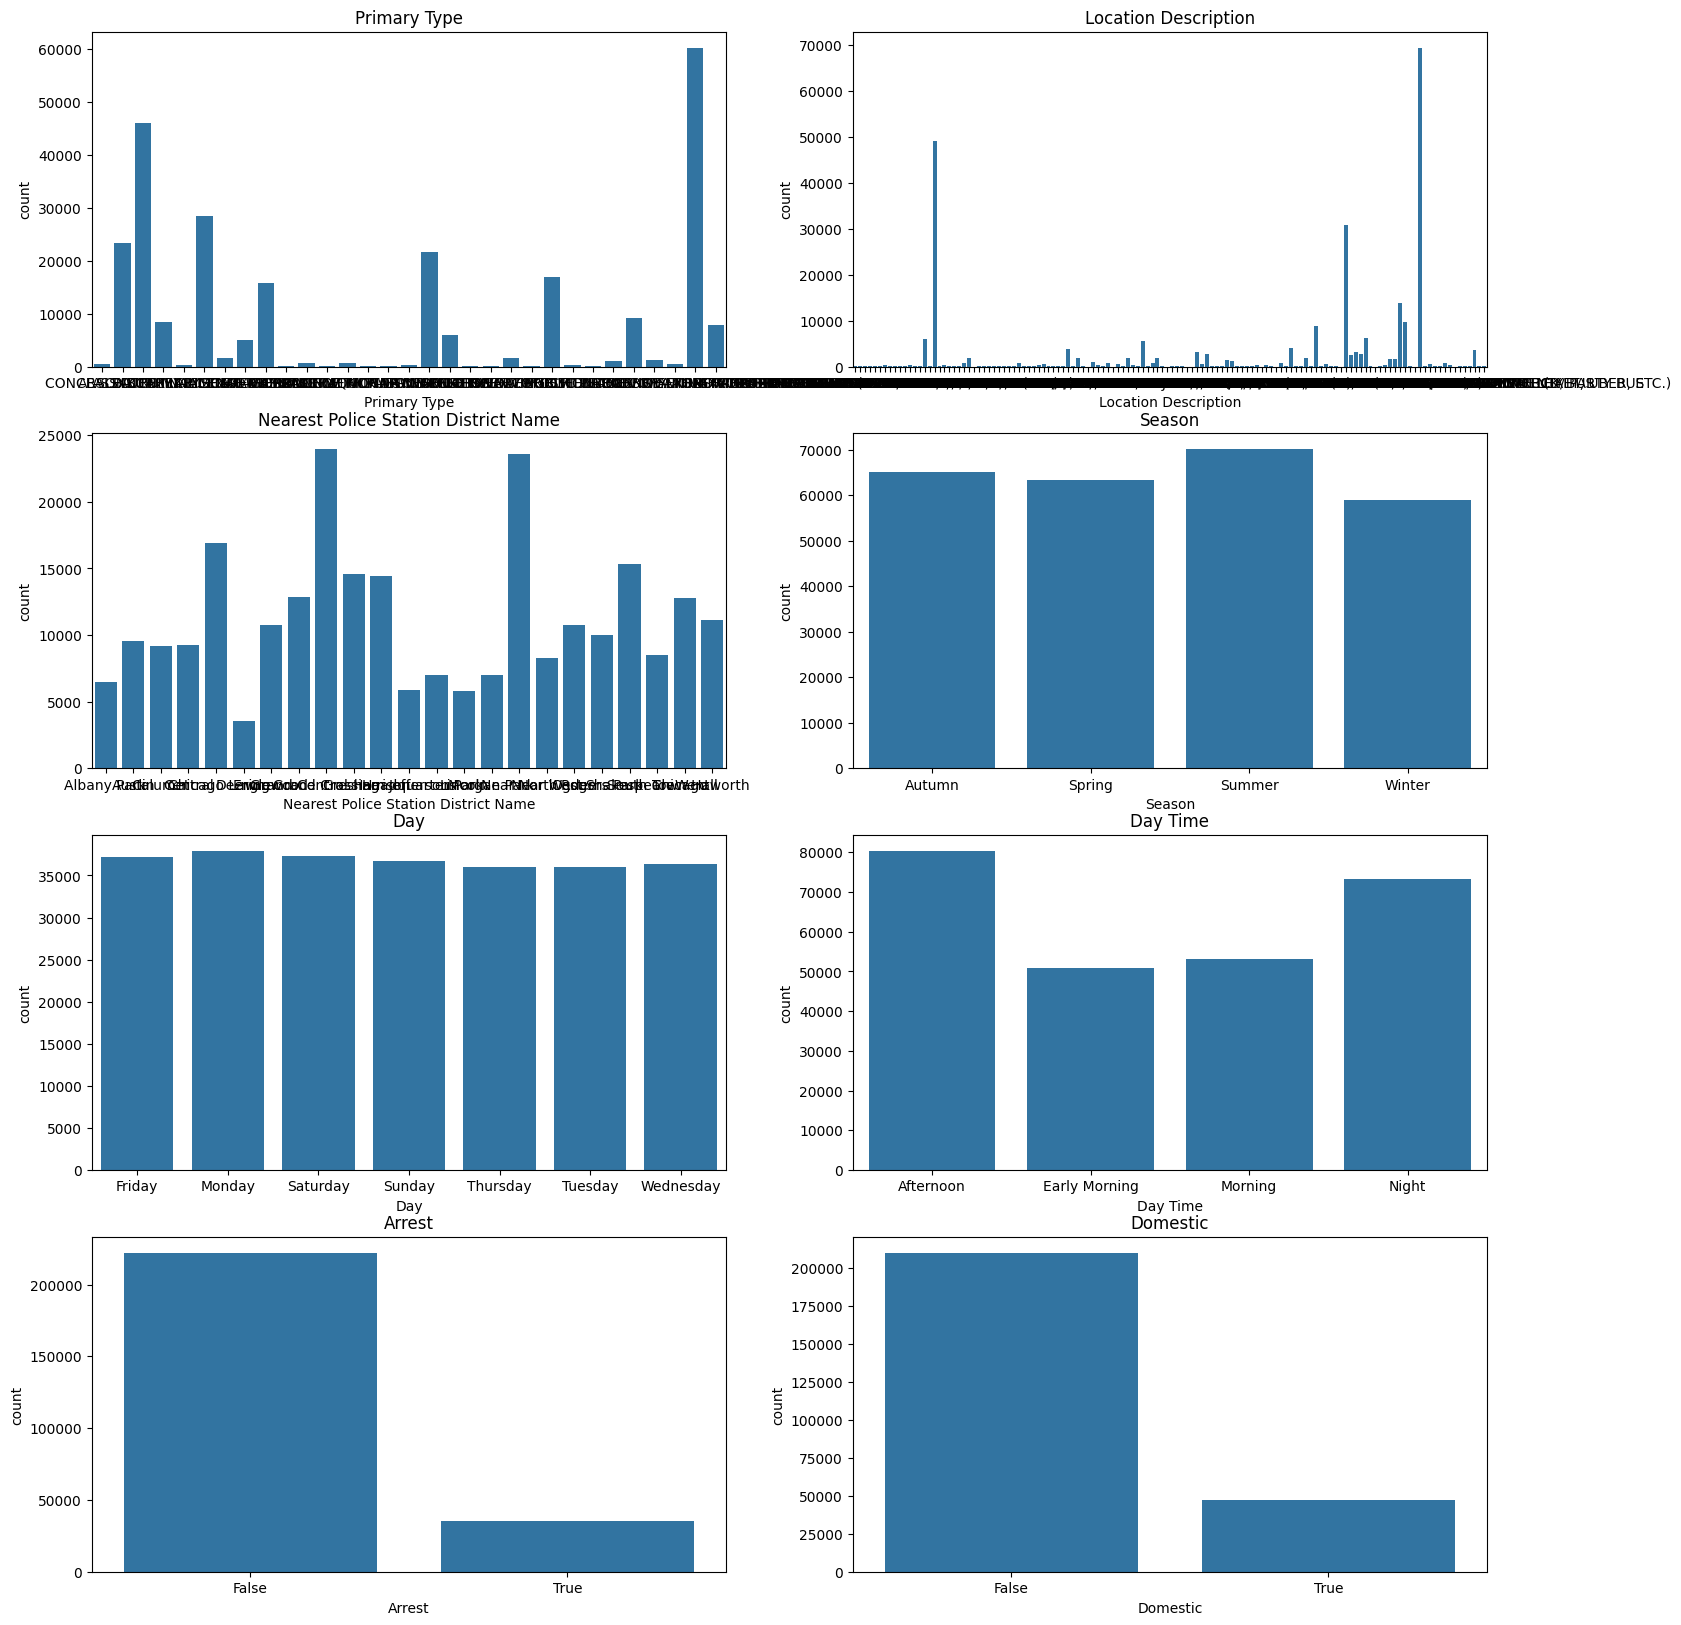

In [ ]:
# Crear cada cajita
fig, ax = plt.subplots(4, 2, figsize=(18, 20))

# Gráficos de barras de cada una
sns.countplot(x='Primary Type', data=df_csv, ax=ax[0,0])
sns.countplot(x='Location Description', data=df_csv, ax=ax[0,1])
sns.countplot(x='Nearest Police Station District Name', data=df_csv, ax=ax[1,0])
sns.countplot(x='Season', data=df_csv, ax=ax[1,1])
sns.countplot(x='Day', data=df_csv, ax=ax[2,0])
sns.countplot(x='Day Time', data=df_csv, ax=ax[2,1])
sns.countplot(x='Arrest', data=df_csv, ax=ax[3,0])
sns.countplot(x='Domestic', data=df_csv, ax=ax[3,1])

# Títulos
ax[0,0].set_title('Primary Type')
ax[0,1].set_title('Location Description')
ax[1,0].set_title('Nearest Police Station District Name')
ax[1,1].set_title('Season')
ax[2,0].set_title('Day')
ax[2,1].set_title('Day Time')
ax[3,0].set_title('Arrest')
ax[3,1].set_title('Domestic')

plt.show()

#### Visualizamos relaciones entre variables

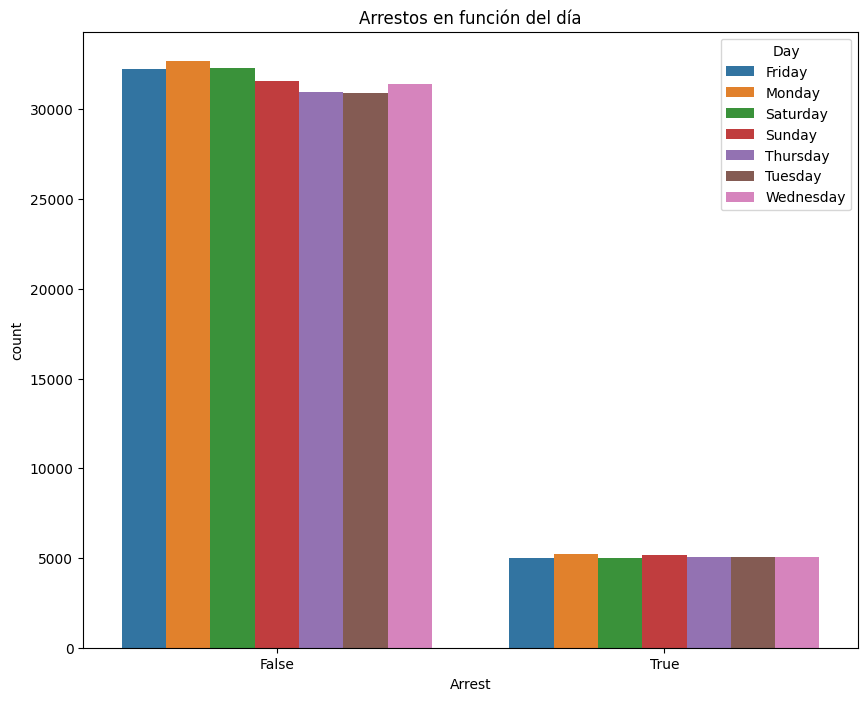

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Arrest', hue='Day', data=df_csv)
plt.title("Arrestos en función del día")
plt.show()

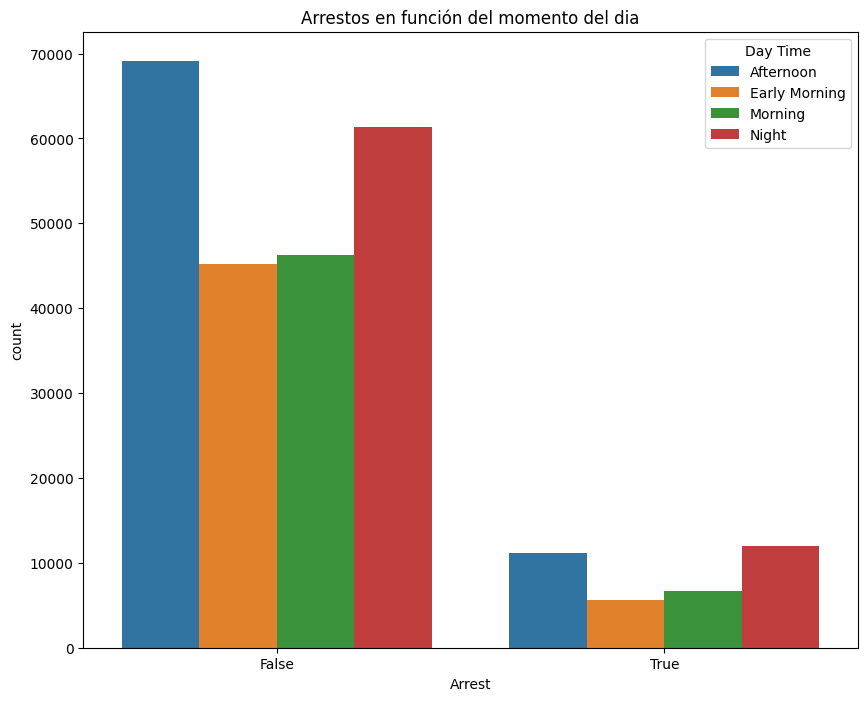

In [ ]:
plt.figure(figsize=(10, 8))
sns.countplot(x='Arrest', hue='Day Time', data=df_csv)
plt.title("Arrestos en función del momento del dia")
plt.show()

#### Pairplot

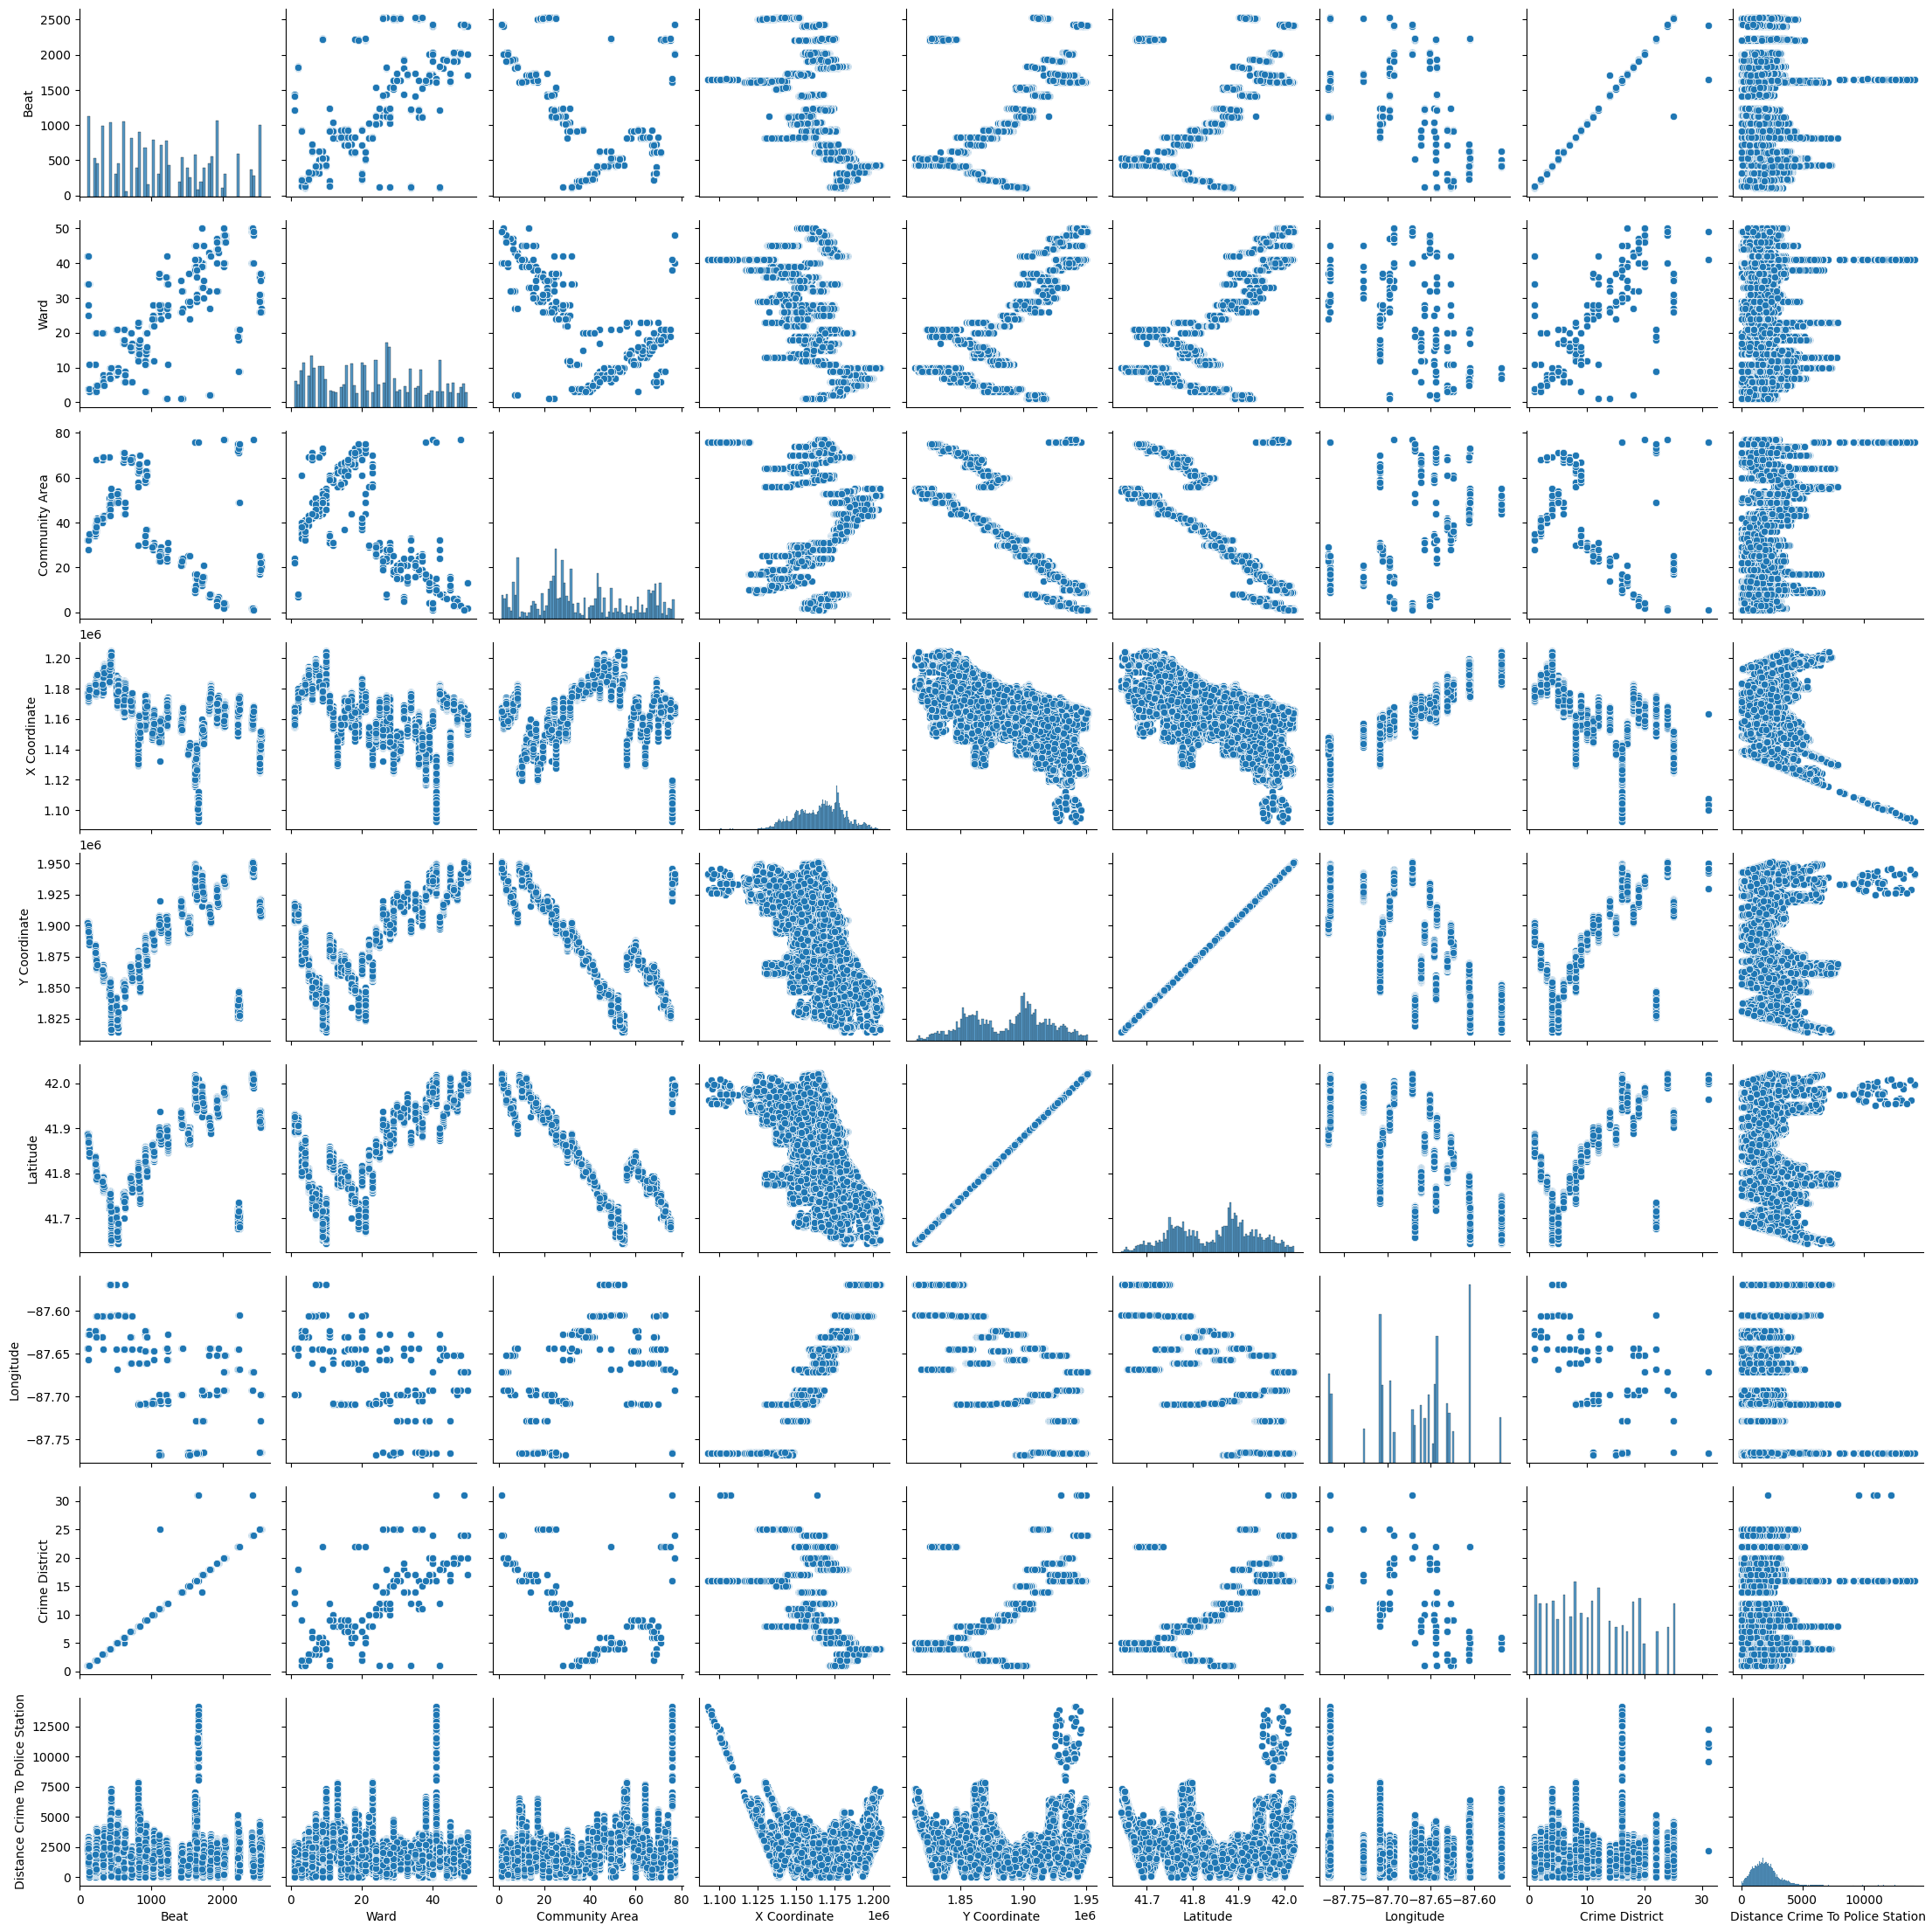

In [ ]:
sns.pairplot(data=df_csv)
plt.show()

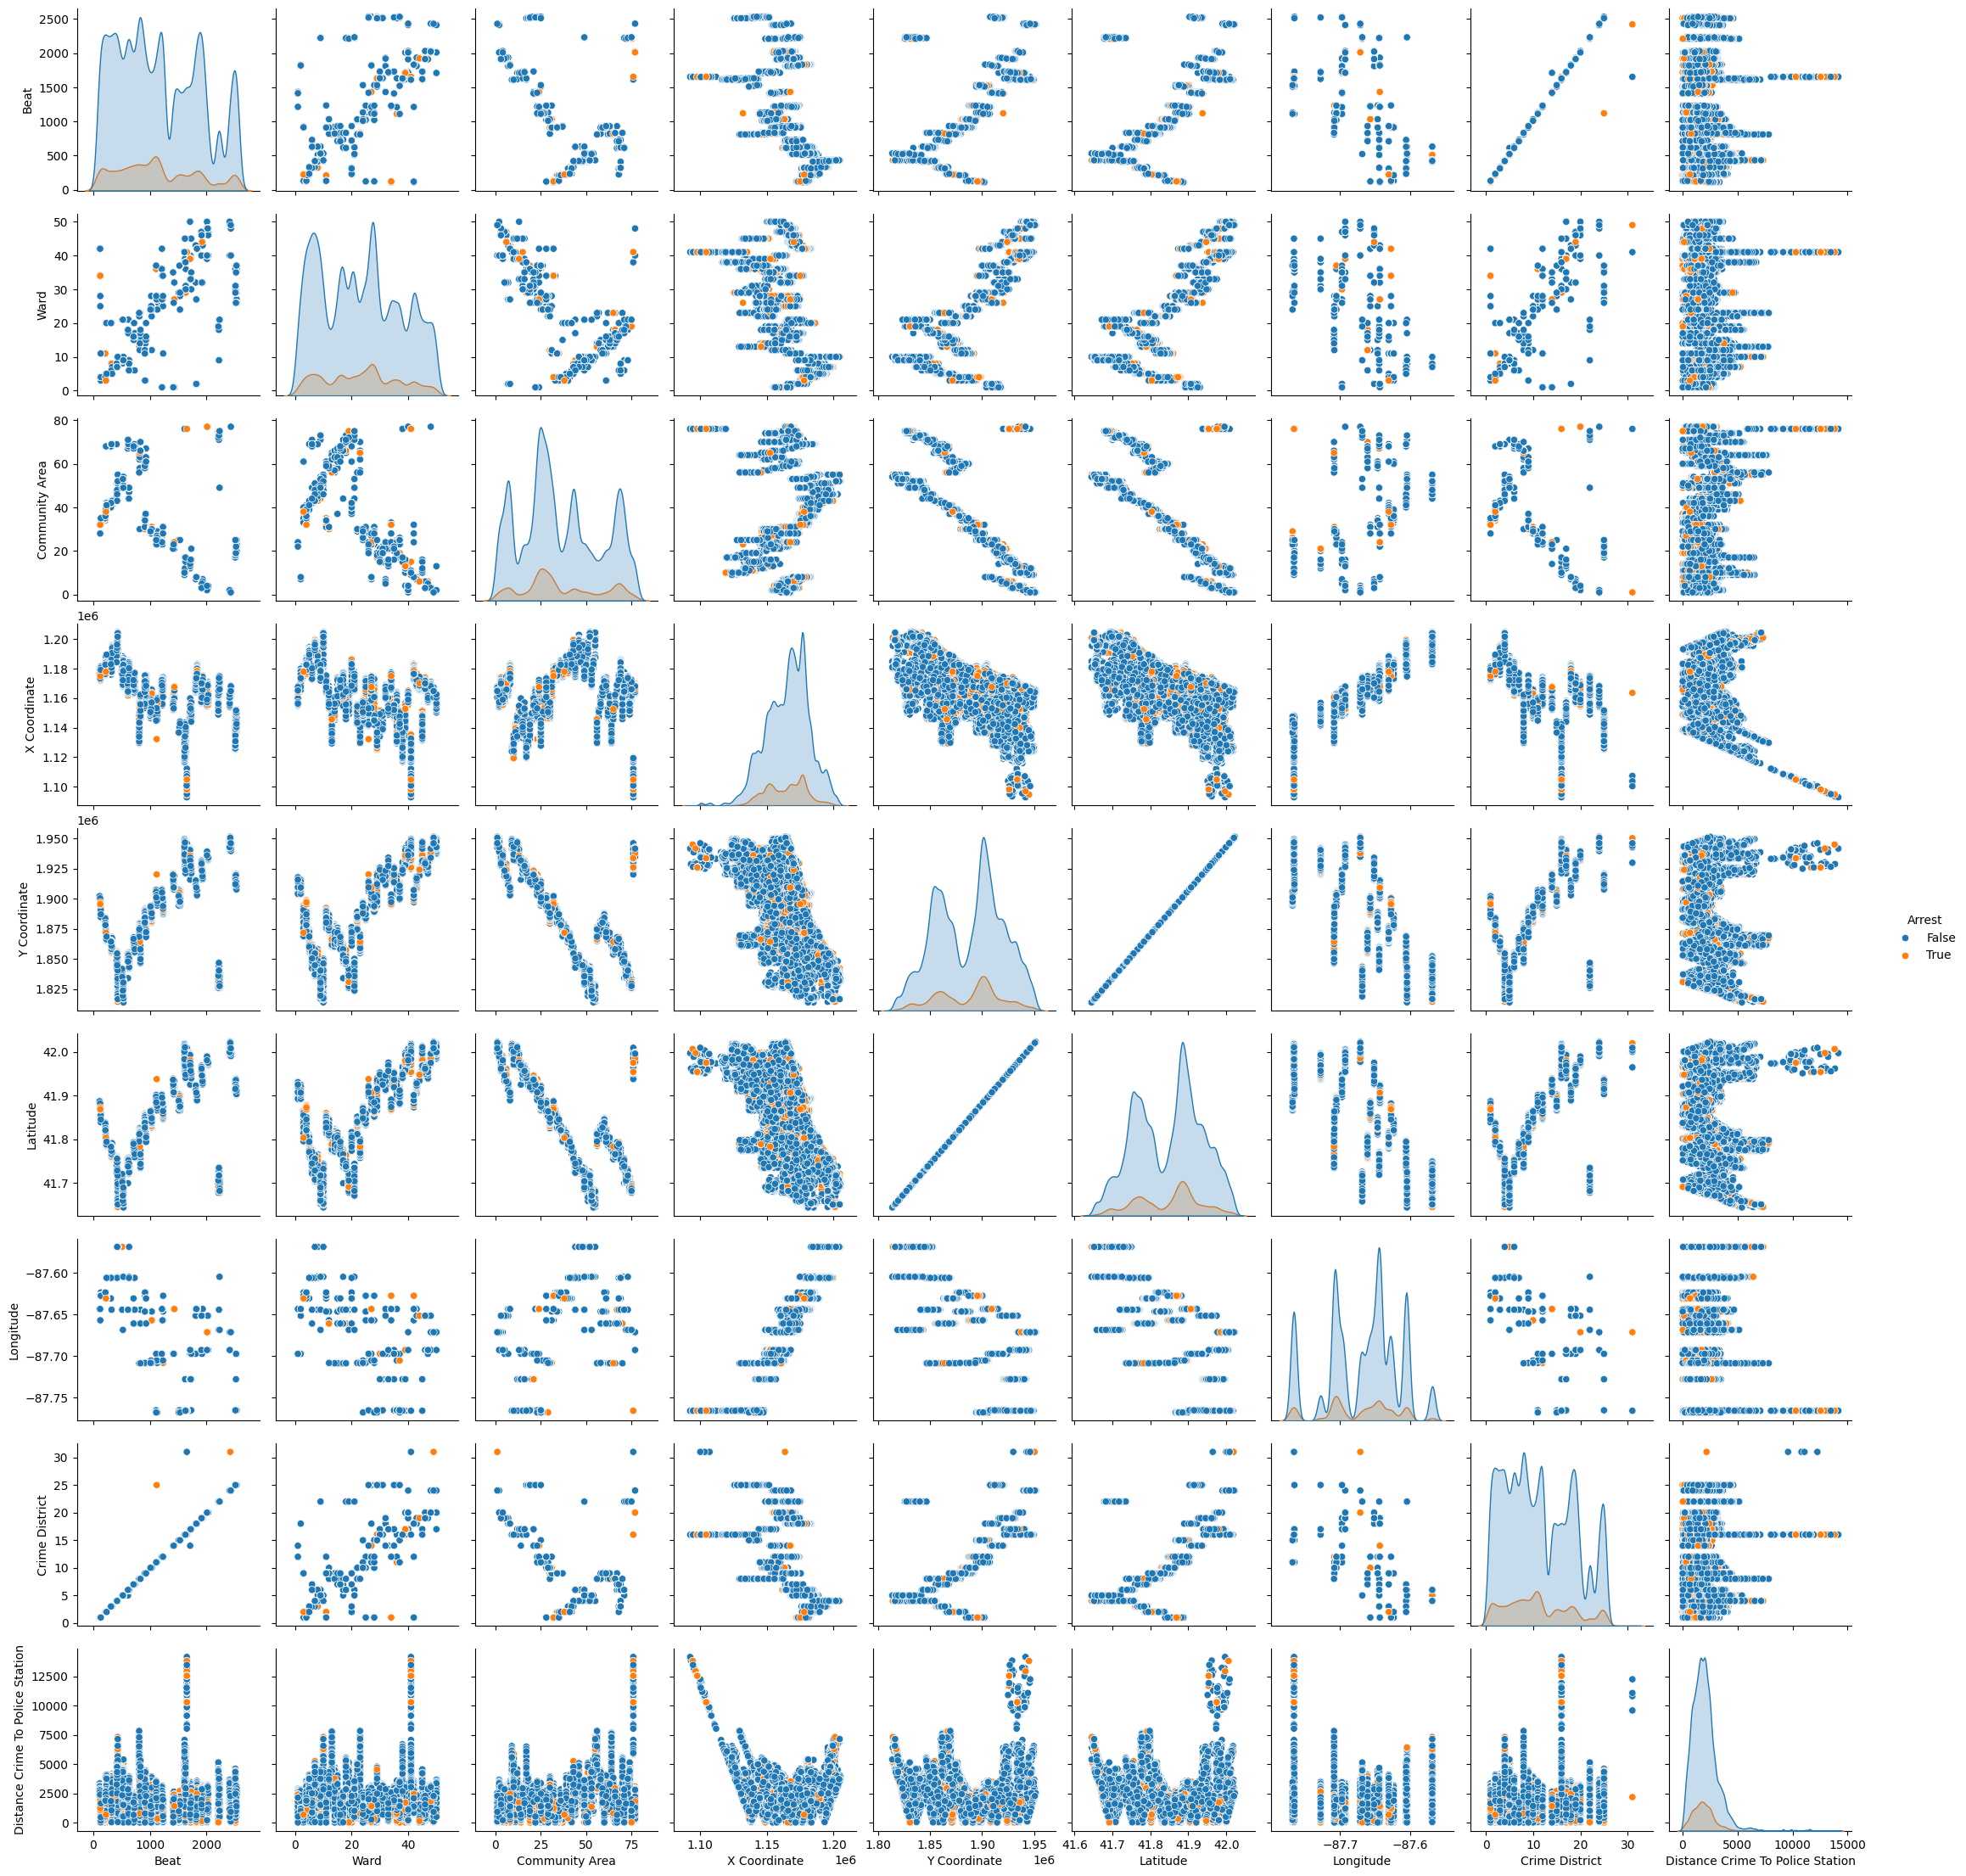

In [ ]:
sns.pairplot(data=df_csv, hue='Arrest')
plt.show()

## Análisis de nulos y outliers

In [ ]:
print(f"Valores faltantes: {df_csv.isnull().sum()}") # Calcular valores faltantes

Valores faltantes: IUCR                                       0
Primary Type                               0
Location Description                    1046
Arrest                                     0
Domestic                                   0
Beat                                       0
Ward                                       0
Community Area                             0
FBI Code                                   0
X Coordinate                               0
Y Coordinate                               0
Latitude                                   0
Longitude                                  0
Crime District                             0
Nearest Police Station District            0
Nearest Police Station District Name       0
Distance Crime To Police Station           0
Season                                     0
Day                                        0
Day Time                                   0
dtype: int64


In [ ]:
df_csv.isna()

,IUCR,Primary Type,Location Description,Arrest,Domestic,Beat,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Latitude,Longitude,Crime District,Nearest Police Station District,Nearest Police Station District Name,Distance Crime To Police Station,Season,Day,Day Time
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
257509,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
257510,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
257511,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
257512,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
df_csv.isna().mean().round(4)*100

,0
IUCR,0.00
Primary Type,0.00
Location Description,0.41
Arrest,0.00
Domestic,0.00
Beat,0.00
Ward,0.00
Community Area,0.00
FBI Code,0.00
X Coordinate,0.00


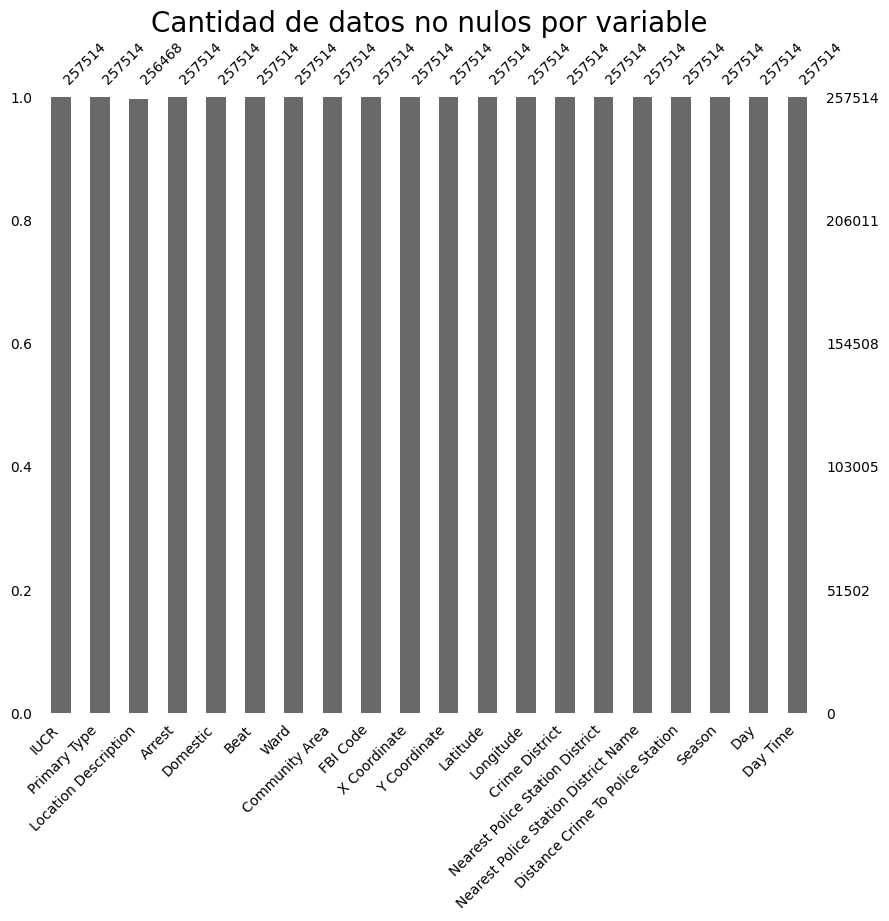

In [ ]:
msno.bar(df_csv, fontsize=10, figsize=(10,8))
plt.title("Cantidad de datos no nulos por variable", fontsize=20)
plt.show()

<Axes: >

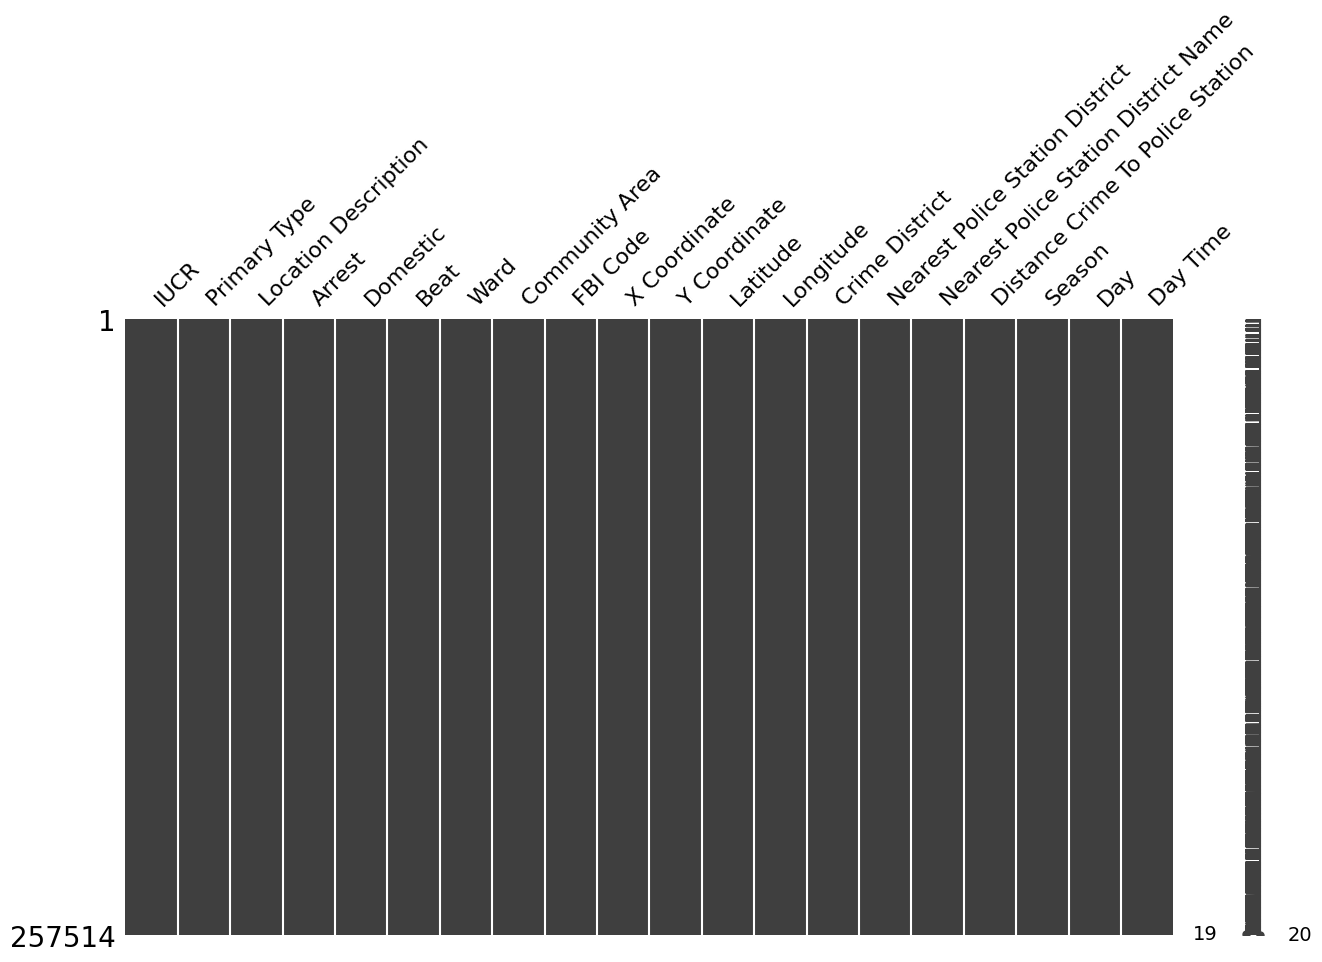

In [ ]:
# Matriz de valores faltantes
msno.matrix(df_csv, figsize=(15,8))

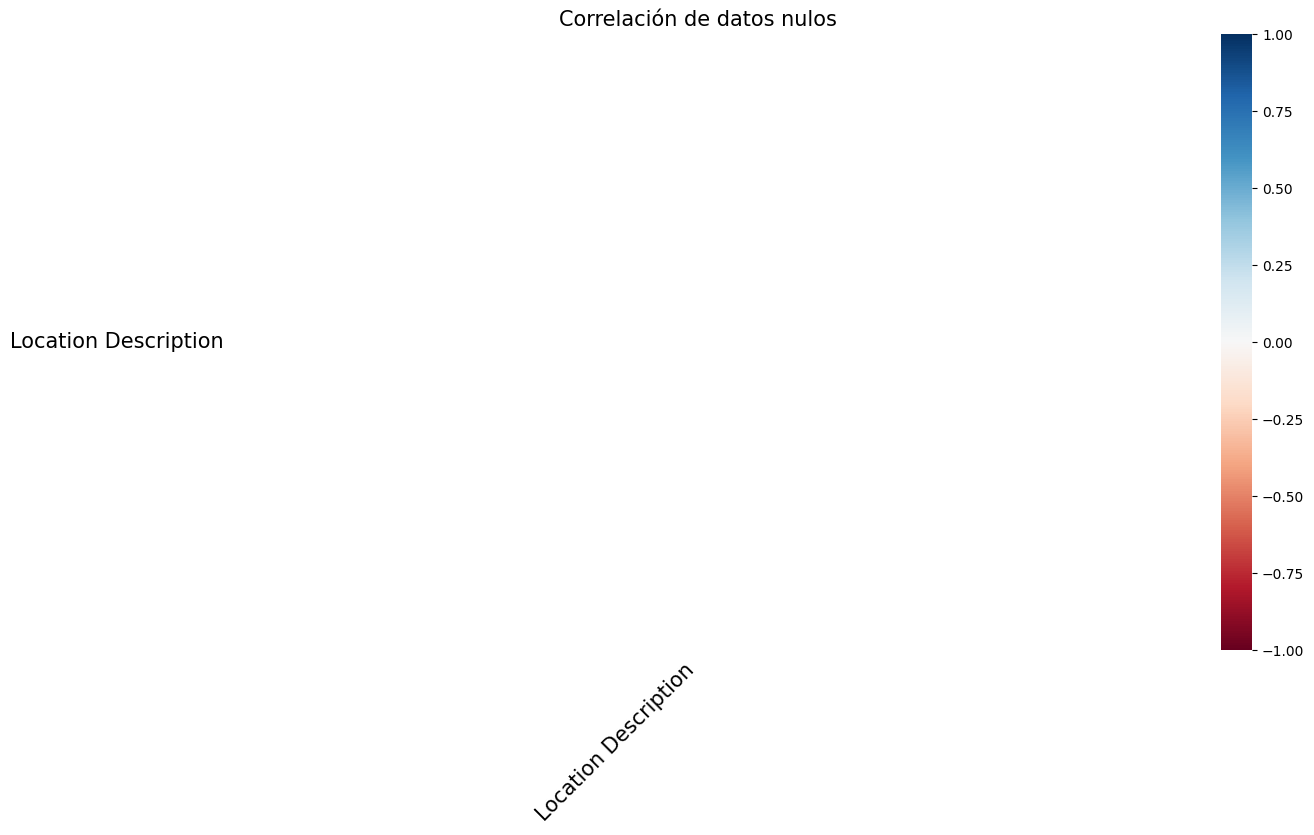

In [ ]:
msno.heatmap(df_csv, fontsize=15, figsize=(15,8))
plt.title("Correlación de datos nulos", fontsize=15)
plt.show()

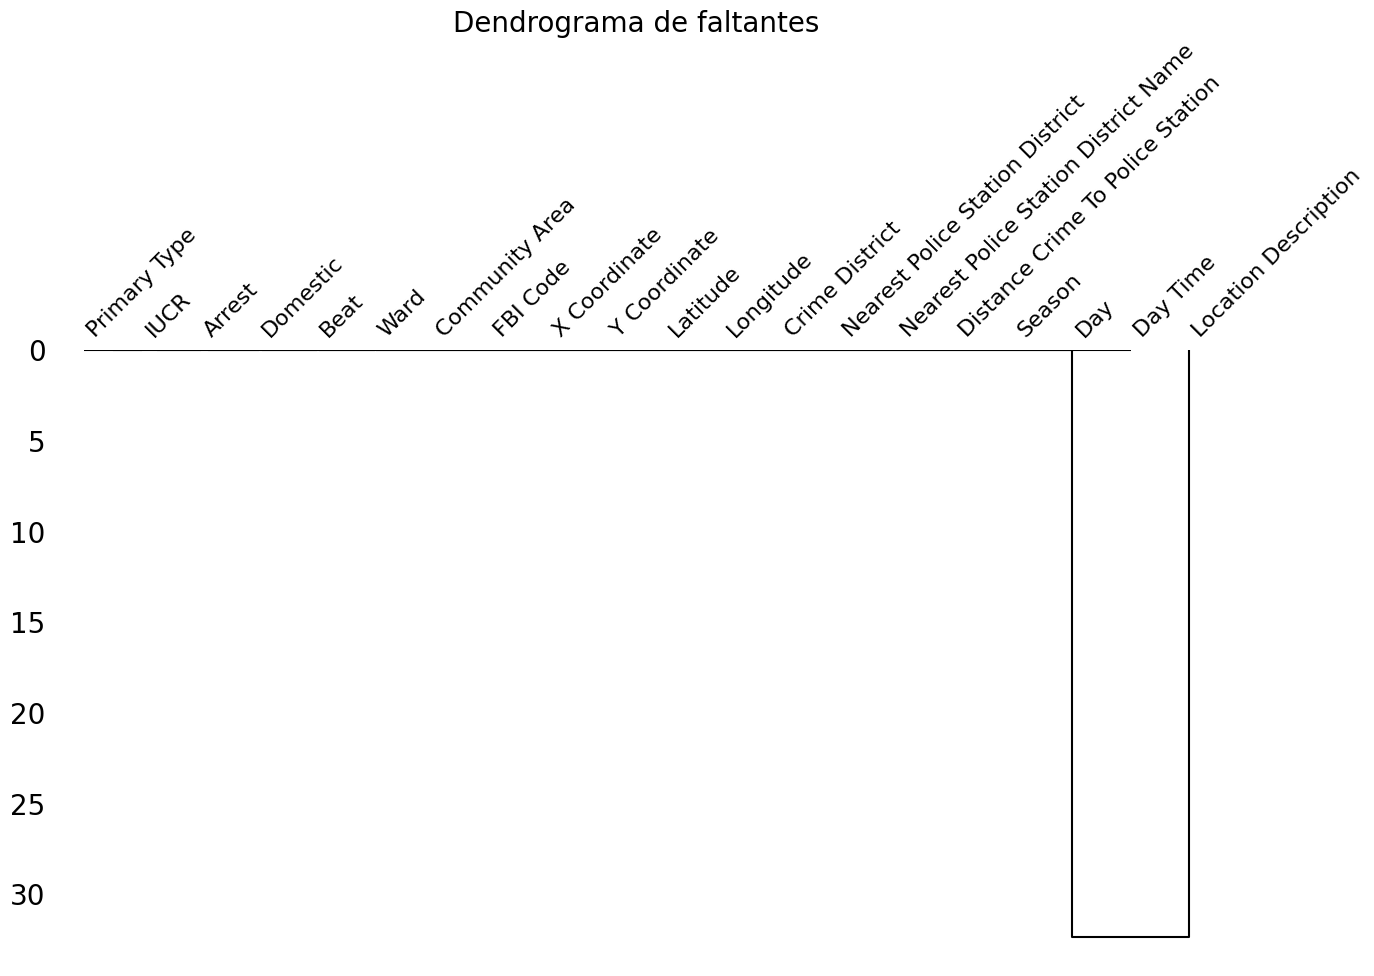

In [ ]:
msno.dendrogram(df_csv, figsize=(15,8))
plt.title('Dendrograma de faltantes', fontsize=20)
plt.show()

In [ ]:
df_for_outliers = df_csv[['Distance Crime To Police Station']]
df_for_outliers

,Distance Crime To Police Station
0,1367.540845
1,1380.313916
2,3982.098345
3,1005.009383
4,1797.243049
...,...
257509,1019.404457
257510,2469.854020
257511,2008.547857
257512,2273.335820


#### Basado en el rango intercuartil

Un dato se considera outlier si es < (Q1 - 1.5 * IQR)) o > (Q3 + 1.5 * IQR)

In [ ]:
Q1 = df_for_outliers.quantile(0.25)
Q3 = df_for_outliers.quantile(0.75)

IQR = Q3 - Q1
outliers_iqr = (df_for_outliers < (Q1 - 1.5 * IQR)) | (df_for_outliers > (Q3 + 1.5 * IQR))
print(f"Outliers\nDistance Crime To Police Station: <{Q1['Distance Crime To Police Station'] - 1.5 * IQR['Distance Crime To Police Station']:.02f} o >{Q3['Distance Crime To Police Station'] + 1.5 * IQR['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <-716.20 o >4445.36


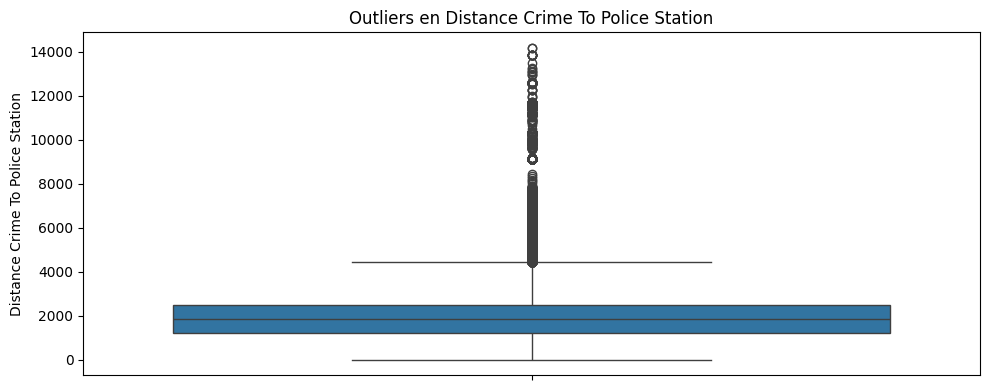

In [ ]:
# Visualización de outliers con boxplots
fig, axes = plt.subplots(1, figsize=(10, 4))

# Boxplot para 'age'
sns.boxplot(y=df_for_outliers['Distance Crime To Police Station'], ax=axes)
axes.set_title('Outliers en Distance Crime To Police Station')

plt.tight_layout()
plt.show()

#### Basado en la desviación estándar (distribución normal)

Un dato se considera outlier si es < (mean - 3 * std) o > (mean + 3 * std)

In [ ]:
# Método basado en desviación estándar
mean = df_for_outliers.mean()
#std = df.std()
std = df_for_outliers.apply(lambda x: np.nanstd(x, ddof=1))

outliers_std = (df_for_outliers < (mean - 3 * std)) | (df_for_outliers > (mean + 3 * std))

print(f"Outliers\nDistance Crime To Police Station: <{mean['Distance Crime To Police Station'] - 3 * std['Distance Crime To Police Station']:.02f} o >{mean['Distance Crime To Police Station'] + 3 * std['Distance Crime To Police Station']:.02f}")

Outliers
Distance Crime To Police Station: <-1643.59 o >5640.15


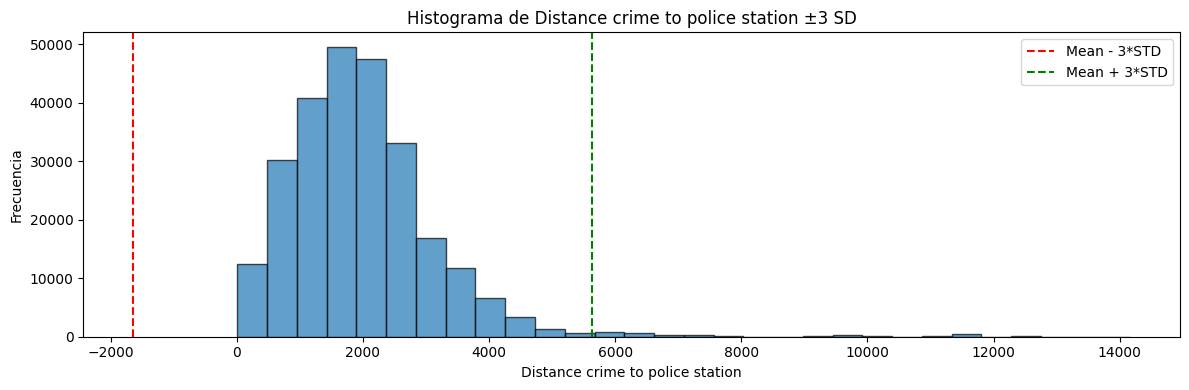

In [ ]:
def plot_hist_with_std(ax, data, varname, mean, std):
    ax.hist(data, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(mean[varname] - 3*std[varname], color='red', linestyle='--', label='Mean - 3*STD')
    ax.axvline(mean[varname] + 3*std[varname], color='green', linestyle='--', label='Mean + 3*STD')
    ax.set_xlabel(varname.capitalize())
    ax.set_ylabel('Frecuencia')
    ax.set_title(f'Histograma de {varname.capitalize()} ±3 SD')
    ax.legend()

fig, ax = plt.subplots(1, figsize=(12, 4))

plot_hist_with_std(ax, df_for_outliers['Distance Crime To Police Station'], 'Distance Crime To Police Station', mean, std)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


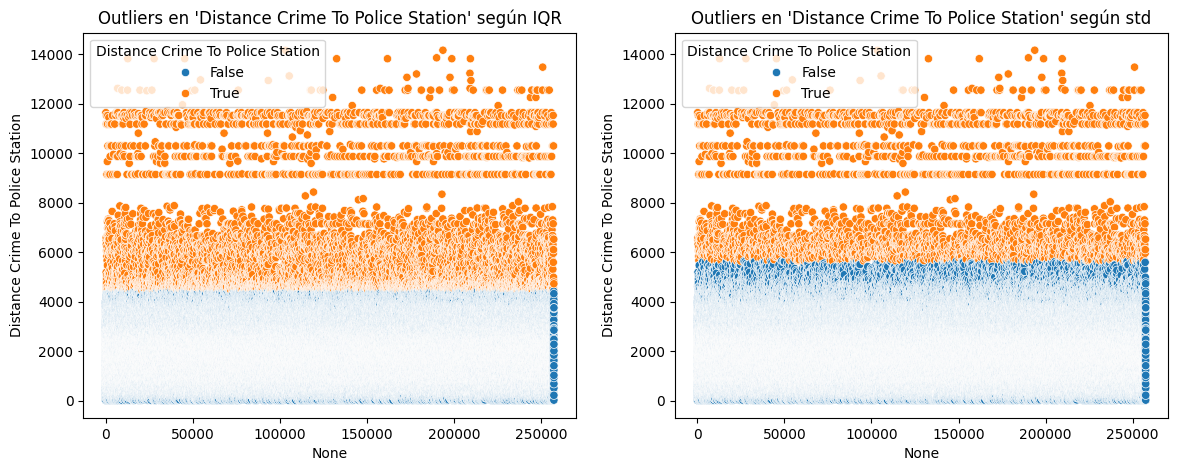

In [ ]:
# Visualización con scatterplot
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_iqr['Distance Crime To Police Station'], ax=ax[0])
ax[0].set_title("Outliers en 'Distance Crime To Police Station' según IQR")
sns.scatterplot(x=df_for_outliers.index, y=df_for_outliers['Distance Crime To Police Station'], hue=outliers_std['Distance Crime To Police Station'], ax=ax[1])
ax[1].set_title("Outliers en 'Distance Crime To Police Station' según std")
plt.show()

In [ ]:
df_csv[outliers_std['Distance Crime To Police Station']==True]["Arrest"].value_counts()

,count
Arrest,
False,2973
True,443
